#Import necessary libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, RFE, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

#Load the dataset

In [49]:
data_path = '/content/ObesityDataSet.csv'
data = pd.read_csv(data_path)


# Inspect the first few rows

In [50]:

print(data.head())


   Gender   Age  Height  Weight family_history_with_overweight  \
0  Female  21.0    1.62    64.0                            yes   
1  Female  21.0    1.52    56.0                            yes   
2    Male  23.0    1.80    77.0                            yes   
3    Male  27.0    1.80    87.0                             no   
4    Male  22.0    1.78    89.8                             no   

  Frequent Consumption of High-Caloric Food (FAVC)  \
0                                               no   
1                                               no   
2                                               no   
3                                               no   
4                                               no   

   Frequency of Vegetable Consumption (FCVC)  Number of Main Meals (NCP)  \
0                                        2.0                         3.0   
1                                        3.0                         3.0   
2                                        2.0      

# Drop rows with NaN values for simplicity

In [51]:

data.dropna(inplace=True)


# Separate features and target

In [52]:

X = data.drop('Obesity Level', axis=1)
y = data['Obesity Level']


# Convert categorical columns to numeric using one-hot encoding

In [53]:

X = pd.get_dummies(X)


# Encode target labels to numeric values



In [54]:

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# Split data into training and testing sets

In [55]:

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)


### 1. Decision Tree with Variance Threshold Feature Selection ###

Decision Tree Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      0.92      0.89        86
      Normal_Weight       0.69      0.67      0.68        93
     Obesity_Type_I       0.90      0.88      0.89       102
    Obesity_Type_II       0.93      0.98      0.96        88
   Obesity_Type_III       1.00      0.99      0.99        98
 Overweight_Level_I       0.73      0.75      0.74        88
Overweight_Level_II       0.75      0.70      0.72        79

           accuracy                           0.84       634
          macro avg       0.84      0.84      0.84       634
       weighted avg       0.84      0.84      0.84       634

Decision Tree Accuracy: 0.8438485804416404


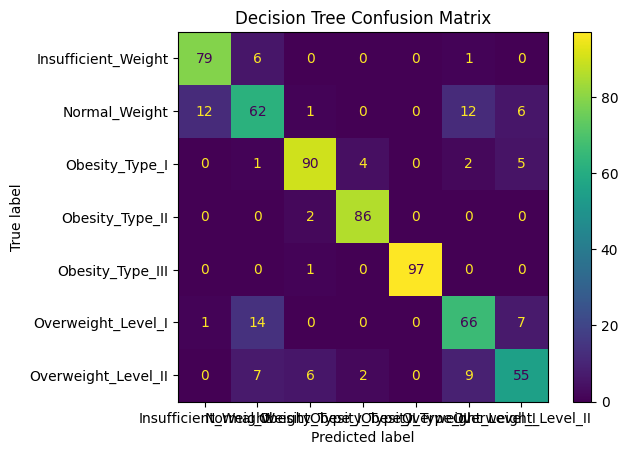

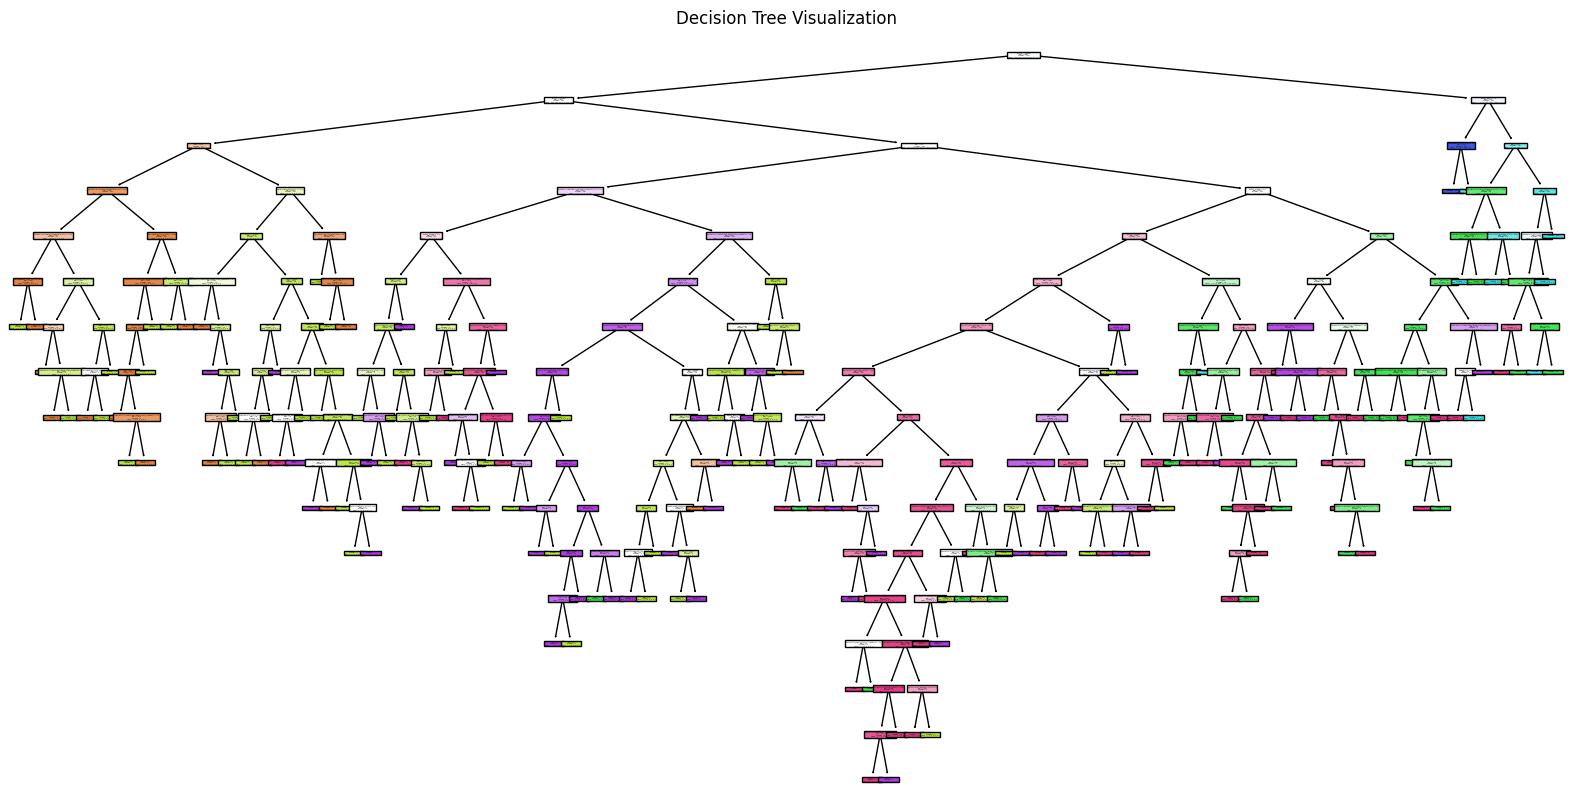

In [56]:

# Apply Variance Threshold
vt_selector = VarianceThreshold(threshold=0.01)
X_train_vt = vt_selector.fit_transform(X_train)
X_test_vt = vt_selector.transform(X_test)

# Train and evaluate Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_vt, y_train)
y_pred_dt = dt_model.predict(X_test_vt)


# Print evaluation metrics
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(dt_model, X_test_vt, y_test, display_labels=label_encoder.classes_)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Plot Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns[vt_selector.get_support()])
plt.title("Decision Tree Visualization")
plt.show()

2. Support Vector Machine (SVM) with Recursive Feature Elimination (RFE)

SVM Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      1.00      0.93        86
      Normal_Weight       1.00      0.69      0.82        93
     Obesity_Type_I       0.98      0.97      0.98       102
    Obesity_Type_II       0.96      0.91      0.94        88
   Obesity_Type_III       0.93      0.99      0.96        98
 Overweight_Level_I       0.80      0.92      0.86        88
Overweight_Level_II       0.90      0.95      0.93        79

           accuracy                           0.92       634
          macro avg       0.92      0.92      0.91       634
       weighted avg       0.93      0.92      0.92       634

SVM Accuracy: 0.917981072555205


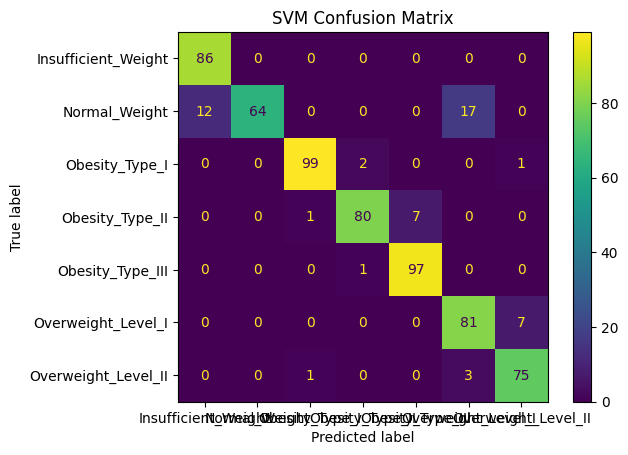

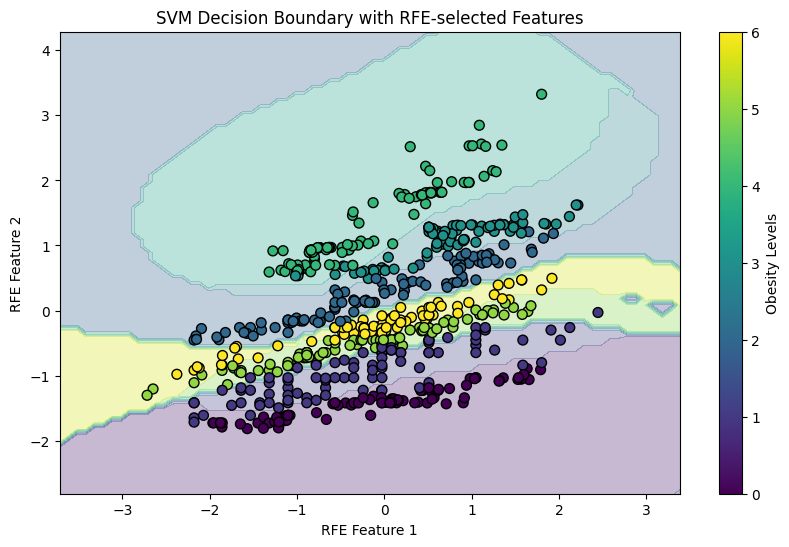

In [57]:

# Scale the data for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply RFE with Logistic Regression as the base estimator to select top 2 features
rfe_selector = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=2)
X_train_rfe = rfe_selector.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe_selector.transform(X_test_scaled)

# Train and evaluate SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_rfe, y_train)
y_pred_svm = svm_model.predict(X_test_rfe)

# Print evaluation metrics
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_rfe, y_test, display_labels=label_encoder.classes_)
plt.title("SVM Confusion Matrix")
plt.show()

# Decision Boundary Plot for SVM with RFE-selected Features
plt.figure(figsize=(10, 6))
x_min, x_max = X_test_rfe[:, 0].min() - 1, X_test_rfe[:, 0].max() + 1
y_min, y_max = X_test_rfe[:, 1].min() - 1, X_test_rfe[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on the mesh grid and ensure labels are numeric
xy_mesh = np.c_[xx.ravel(), yy.ravel()]
Z = svm_model.predict(xy_mesh)
Z = Z.reshape(xx.shape)

# Plot decision boundary and scatter plot of actual data points
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_test_rfe[:, 0], X_test_rfe[:, 1], c=y_test, cmap='viridis', edgecolor='k', s=50)
plt.xlabel("RFE Feature 1")
plt.ylabel("RFE Feature 2")
plt.title("SVM Decision Boundary with RFE-selected Features")
plt.colorbar(scatter, label="Obesity Levels")
plt.show()


3. Random Forest with SelectKBest Feature Selection




Random Forest Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.90      0.88        86
      Normal_Weight       0.71      0.59      0.64        93
     Obesity_Type_I       0.71      0.69      0.70       102
    Obesity_Type_II       0.80      0.83      0.82        88
   Obesity_Type_III       1.00      0.99      0.99        98
 Overweight_Level_I       0.55      0.64      0.59        88
Overweight_Level_II       0.51      0.51      0.51        79

           accuracy                           0.74       634
          macro avg       0.73      0.73      0.73       634
       weighted avg       0.74      0.74      0.74       634

Random Forest Accuracy: 0.7381703470031545


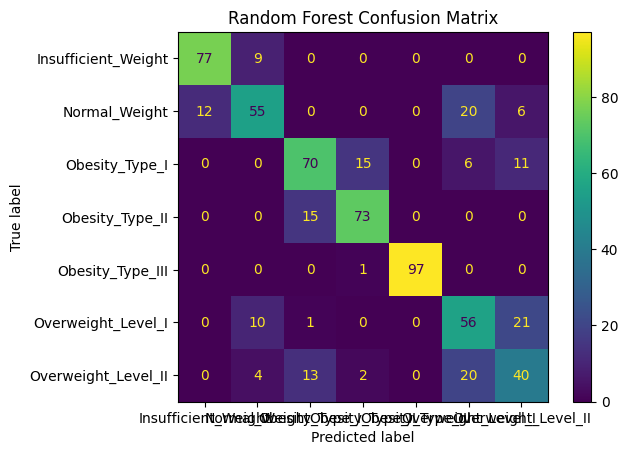

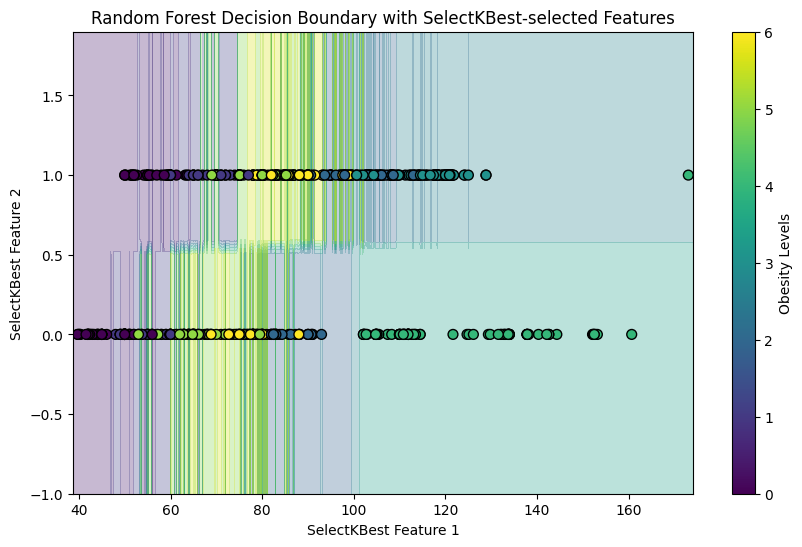

In [58]:
# Apply SelectKBest to select the top 2 features
kbest_selector = SelectKBest(score_func=f_classif, k=2)
X_train_kbest = kbest_selector.fit_transform(X_train, y_train)
X_test_kbest = kbest_selector.transform(X_test)

# Train and evaluate Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_kbest, y_train)
y_pred_rf = rf_model.predict(X_test_kbest)

# Print evaluation metrics
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Display confusion matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_kbest, y_test, display_labels=label_encoder.classes_)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Decision Boundary Plot for Random Forest with SelectKBest-selected Features
plt.figure(figsize=(10, 6))
x_min, x_max = X_test_kbest[:, 0].min() - 1, X_test_kbest[:, 0].max() + 1
y_min, y_max = X_test_kbest[:, 1].min() - 1, X_test_kbest[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on the mesh grid for Random Forest
Z = rf_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision boundary and scatter plot of actual data points
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_test_kbest[:, 0], X_test_kbest[:, 1], c=y_test, cmap='viridis', edgecolor='k', s=50)
plt.xlabel("SelectKBest Feature 1")
plt.ylabel("SelectKBest Feature 2")
plt.title("Random Forest Decision Boundary with SelectKBest-selected Features")
plt.colorbar(scatter, label="Obesity Levels")
plt.show()